# Brain Tumor Detection: From Data to Decision

This notebook documents the Exploratory Data Analysis (EDA) that drove our architectural choices. By understanding the data's geometry, balance, and complexity, we designed a custom CNN specifically tailored for this problem.

In [1]:
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Setup paths (Using the structure defined in README)
base_dir = Path('data/brain_tumor_dataset')
tumor_dir = base_dir / 'Brain Tumor'
healthy_dir = base_dir / 'Healthy'

# Ensure paths exist
if not base_dir.exists():
    print("WARNING: Data directory not found. Please download data as per README instructions.")

## 1. Class Distribution: The Foundation of Loss Strategy
**Goal:** Check if we have a balanced dataset. Severe imbalance would require weighted loss functions.

**Architectural Impact:** 
- If balanced: Standard `NLLLoss` or `CrossEntropy` is sufficient.
- If unbalanced: We would need `ClassWeighted` loss.

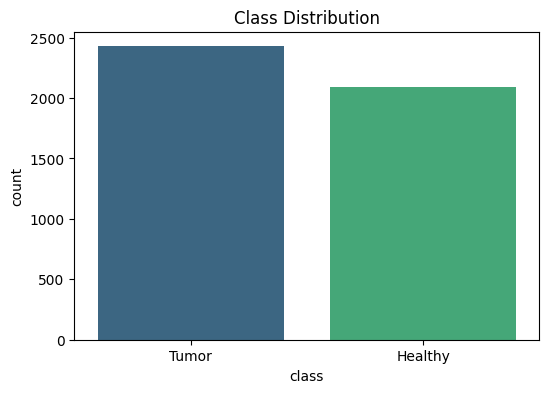

Total Tumor Images: 2427
Total Healthy Images: 2087


In [7]:
tumor_files = list(tumor_dir.glob('*.jpg')) + list(tumor_dir.glob('*.png')) + list(tumor_dir.glob('*.jpeg'))
healthy_files = list(healthy_dir.glob('*.jpg')) + list(healthy_dir.glob('*.png')) + list(healthy_dir.glob('*.jpeg'))

df = pd.DataFrame({
    'class': ['Tumor'] * len(tumor_files) + ['Healthy'] * len(healthy_files),
    'path': tumor_files + healthy_files
})

plt.figure(figsize=(6, 4))
sns.countplot(x='class', data=df, hue='class', palette='viridis')
plt.title('Class Distribution')
plt.show()

print(f"Total Tumor Images: {len(tumor_files)}")
print(f"Total Healthy Images: {len(healthy_files)}")

## 2. Image Dimentions: The Case for Adaptive Pooling
**Goal:** Medical images often come from different machines with different resolutions. We need to see the variance in Width and Height.

**Architectural Impact:**
- **High Variance?** -> If we just flattened the output of the last Conv layer, `Linear` layers would crash with mismatched dimensions.
- **Solution:** We use **AdaptiveAvgPool** at the end of the feature extractor. This forces *any* input size into a fixed 1x1 vector, making the network robust to input sizes.

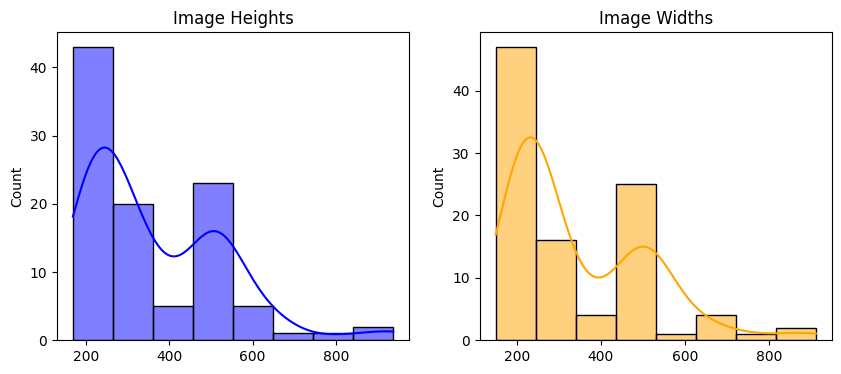

In [3]:
heights = []
widths = []

# Sample 100 images for speed
for p in df['path'].sample(100, random_state=42):
    img = cv2.imread(str(p))
    if img is not None:
        h, w, _ = img.shape
        heights.append(h)
        widths.append(w)

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
sns.histplot(heights, kde=True, color='blue')
plt.title('Image Heights')

plt.subplot(1, 2, 2)
sns.histplot(widths, kde=True, color='orange')
plt.title('Image Widths')
plt.show()

## 3. Pixel Intensity & Contrast: Justifying Normalization
**Goal:** Do tumor images have a different brightness profile? Are the images RGB or Grayscale?

**Architectural Impact:**
- **Input Channels:** Even though MRI is grayscale, file formats often save as 3-channel RGB. We confirmed `Cin=3` in our model to handle standard image loaders.
- **Normalization:** Pixel values vary wildly (0-255). To help the Gradient Descent converge, we apply `transforms.Normalize`.

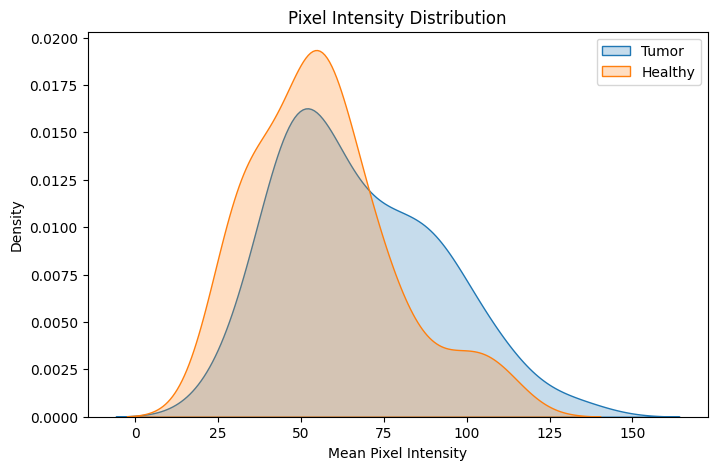

In [4]:
def get_pixel_stats(files):
    means = []
    for p in files[:50]:  # Sample 50
        img = cv2.imread(str(p), cv2.IMREAD_GRAYSCALE)
        if img is not None:
            means.append(np.mean(img))
    return means

tumor_means = get_pixel_stats(tumor_files)
healthy_means = get_pixel_stats(healthy_files)

plt.figure(figsize=(8, 5))
sns.kdeplot(tumor_means, label='Tumor', fill=True)
sns.kdeplot(healthy_means, label='Healthy', fill=True)
plt.title('Pixel Intensity Distribution')
plt.xlabel('Mean Pixel Intensity')
plt.legend()
plt.show()

## 4. Visual Complexity: Why 4 Conv Layers?
**Goal:** Visualize the texture and structure of the tumors.

**Architectural Impact:**
- Tumors are not just "blobs"; they have texture and complex boundaries.
- **Choice:** A shallow 1-2 layer network might miss these textures. We chose **4 Convolutional Layers** with doubling filters (16 -> 32 -> 64 -> 128).
- **Why?** First layers catch edges. Deeper layers catch complex textures (tumor mass). The doubling filter count allows the network to learn more complex combinations of features as it goes deeper.

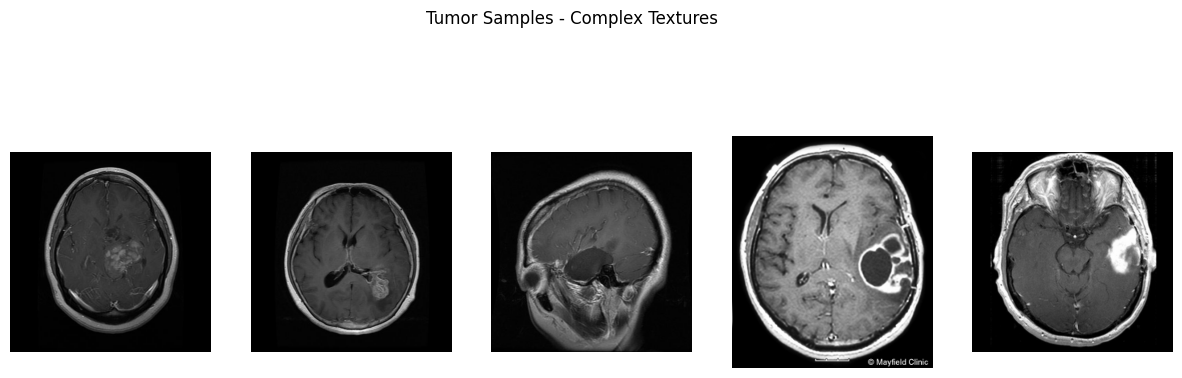

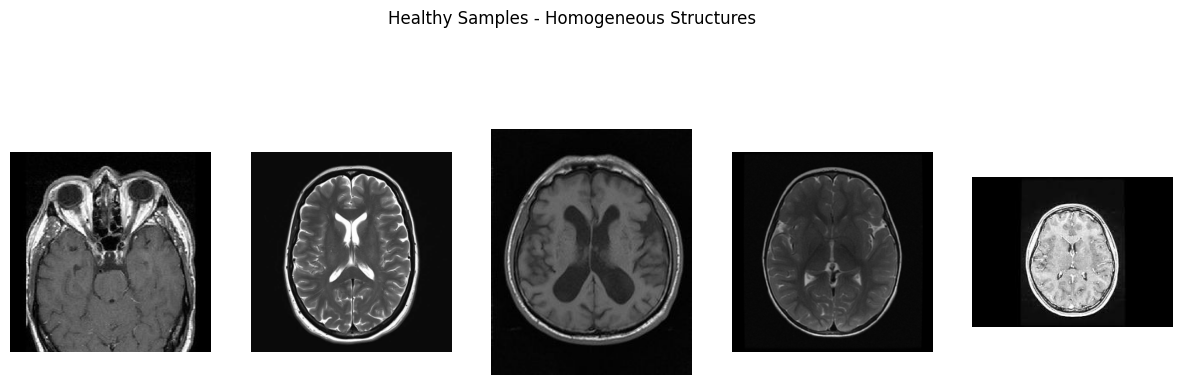

In [5]:
def plot_samples(files, title):
    plt.figure(figsize=(15, 5))
    for i in range(5):
        plt.subplot(1, 5, i+1)
        img = cv2.imread(str(files[i]))
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        plt.imshow(img)
        plt.axis('off')
    plt.suptitle(title)
    plt.show()

plot_samples(tumor_files[:5], 'Tumor Samples - Complex Textures')
plot_samples(healthy_files[:5], 'Healthy Samples - Homogeneous Structures')

## 5. Dataset Size vs. Param Count: The Dropout Decision
**Goal:** Compare the number of training examples to the complexity of the problem.

**Architectural Impact:**
- We have approx 4600 images.
- A 4-layer CNN has thousands of parameters.
- **Risk:** Overfitting (memorizing the specific 4600 images).
- **Solution:** We added **Dropout (0.25)**. This randomly kills 25% of neurons during training, forcing the network to learn robust features rather than memorizing noise.

In [6]:
print(f"Total Images: {len(df)}")
if len(df) < 5000:
    print("Dataset is SMALL (< 5k). High risk of Overfitting.")
    print("RECOMMENDATION: Use Dropout layers and strong Data Augmentation.")
else:
    print("Dataset is Large. Standard regularization might be enough.")

Total Images: 4514
Dataset is SMALL (< 5k). High risk of Overfitting.
RECOMMENDATION: Use Dropout layers and strong Data Augmentation.
